# 01 · Your first complete ChemWorld experiment

**Goal.** Read the public Reaction-to-Assay contract, validate a typed recipe, collect intermediate HPLC feedback, terminate explicitly and inspect the final assay and resource ledger.

> 中文提示：本教程逐步展示 Agent 能看到的公开接口与观测，不读取隐藏世界状态，也不调用外部模型 Provider。

This is a reproducible interface walkthrough, not an optimized chemical procedure.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "chemworld-bench[notebooks] @ git+https://github.com/sunyrain/ChemWorld-Public.git@v0.3.0",
    ])

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import chemworld

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (9, 3.8), "figure.dpi": 110})
print(f"ChemWorld {chemworld.__version__} · provider-free deterministic tutorial")


ChemWorld 0.3.0 · provider-free deterministic tutorial


## 1. Inspect the public contract before acting


In [2]:
env = gym.make("ChemWorld", task_id="reaction-to-assay", seed=0)
_observation, _info = env.reset(seed=0)
prompt = env.unwrapped.task_prompt()
contract = pd.DataFrame({
    "field": ["task_id", "objective", "episode_mode", "allowed_instruments", "success_metrics", "safety_limit"],
    "public value": [
        prompt["task_id"], prompt["objective"], prompt["episode_mode"],
        prompt["allowed_instruments"], prompt["success_metrics"], prompt["safety_limit"],
    ],
})
display(contract)

heat_schema = env.unwrapped.action_schema("heat")
display(pd.DataFrame(heat_schema["fields"])[["field", "unit", "required", "bounds"]])
env.close()


,field,public value
0,task_id,reaction-to-assay
1,objective,balanced
2,episode_mode,single_experiment
3,allowed_instruments,"[final_assay, gc, hplc, uvvis]"
4,success_metrics,"[final_assay_score, trajectory_validity]"
5,safety_limit,0.65


,field,unit,required,bounds
0,target_temperature_K,K,True,"{'low': 250.0, 'high': 470.0}"
1,duration_s,s,True,"{'low': 1.0, 'high': 14400.0}"
2,stirring_speed_rpm,rpm,True,"{'low': 100.0, 'high': 1200.0}"


## 2. Define a typed action sequence


In [3]:
recipe = [
    {"operation": "add_solvent", "volume_L": 0.030, "solvent": 1},
    {"operation": "add_reagent", "amount_mol": 0.012},
    {"operation": "add_catalyst", "catalyst": 2, "catalyst_amount_mol": 0.0004},
    {"operation": "heat", "target_temperature_K": 350.0, "duration_s": 1200.0, "stirring_speed_rpm": 800.0},
    {"operation": "sample", "sample_volume_L": 0.0005},
    {"operation": "measure", "instrument": "hplc"},
    {"operation": "quench"},
    {"operation": "terminate"},
    {"operation": "measure", "instrument": "final_assay"},
]
display(pd.DataFrame([
    {"step": step, "operation": action["operation"], "public payload": {k: v for k, v in action.items() if k != "operation"}}
    for step, action in enumerate(recipe, start=1)
]))


,step,operation,public payload
0,1,add_solvent,"{'volume_L': 0.03, 'solvent': 1}"
1,2,add_reagent,{'amount_mol': 0.012}
2,3,add_catalyst,"{'catalyst': 2, 'catalyst_amount_mol': 0.0004}"
3,4,heat,"{'target_temperature_K': 350.0, 'duration_s': ..."
4,5,sample,{'sample_volume_L': 0.0005}
5,6,measure,{'instrument': 'hplc'}
6,7,quench,{}
7,8,terminate,{}
8,9,measure,{'instrument': 'final_assay'}


In [4]:
def run_recipe(task_id: str, recipe: list[dict], *, seed: int = 0) -> tuple[pd.DataFrame, dict]:
    """Execute typed actions while retaining public validation and resource fields."""
    env = gym.make("ChemWorld", task_id=task_id, seed=seed)
    _observation, info = env.reset(seed=seed)
    rows = []
    final_info = info
    try:
        for step, action in enumerate(recipe, start=1):
            validation = env.unwrapped.validate_action(action)
            _observation, reward, terminated, truncated, info = env.step(action)
            final_info = dict(info)
            rows.append({
                "step": step,
                "operation": action["operation"],
                "valid": bool(validation["valid"]),
                "transaction": info.get("transaction_status"),
                "reward": float(reward),
                "leaderboard_score": info.get("leaderboard_score"),
                "cost_total": info.get("cost"),
                "cost_delta": info.get("cost_delta"),
                "sample_delta_L": info.get("sample_delta"),
                "risk_delta": info.get("risk_delta"),
                "observed_keys": ", ".join(info.get("observed_keys", ())),
                "terminated": bool(terminated),
                "truncated": bool(truncated),
            })
            if terminated or truncated:
                break
    finally:
        env.close()
    frame = pd.DataFrame(rows)
    assert frame["valid"].all(), "Every tutorial request must validate before execution."
    assert frame["transaction"].eq("committed").all(), "Every tutorial action must commit."
    return frame, final_info


## 3. Execute, observe and account for resources


In [5]:
trace, final_info = run_recipe("reaction-to-assay", recipe, seed=0)
display(trace)

assert trace.iloc[-2]["operation"] == "terminate"
assert trace.iloc[-1]["operation"] == "measure"
assert final_info.get("instrument") == "final_assay"


,step,operation,valid,transaction,reward,leaderboard_score,cost_total,cost_delta,sample_delta_L,risk_delta,observed_keys,terminated,truncated
0,1,add_solvent,True,committed,0.0000,NaN,0.0,0.0192,0.0000,0.0597,"cost, safety_risk, score",False,False
1,2,add_reagent,True,committed,0.0000,NaN,0.0,0.0360,0.0000,0.0230,"cost, safety_risk, score",False,False
2,3,add_catalyst,True,committed,0.0000,NaN,0.0,0.1920,0.0000,0.0000,"cost, safety_risk, score",False,False
3,4,heat,True,committed,0.0000,NaN,0.0,0.0100,0.0000,0.0102,"cost, safety_risk, score",False,False
4,5,sample,True,committed,0.0000,NaN,0.0,0.0100,0.0005,0.0000,"cost, safety_risk, score",False,False
5,6,measure,True,committed,0.1239,NaN,0.0,0.0800,0.0002,0.0000,"yield, selectivity, conversion, byproduct_sign...",False,False
6,7,quench,True,committed,0.0000,NaN,0.0,0.0511,0.0000,-0.0070,"yield, selectivity, conversion, byproduct_sign...",False,False
7,8,terminate,True,committed,0.0000,NaN,0.0,0.0000,0.0000,0.0000,"yield, selectivity, conversion, byproduct_sign...",False,False
8,9,measure,True,committed,-0.0383,0.0857,0.0,0.1600,0.0003,0.0000,"yield, selectivity, conversion, byproduct_sign...",True,False


## 4. See how the public signal changes across the lifecycle


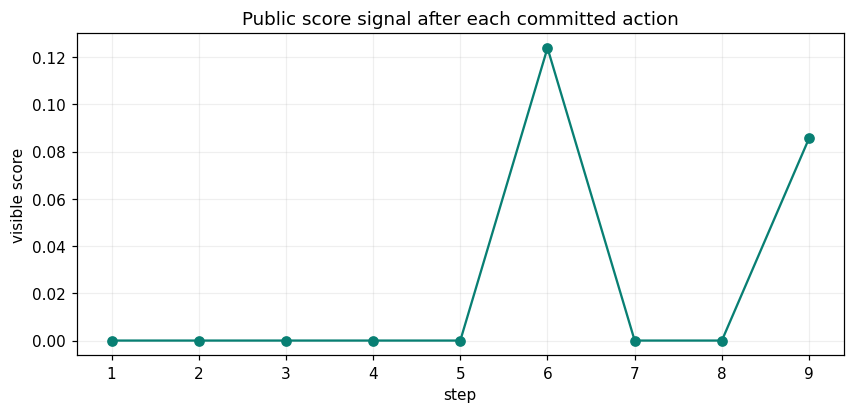

,metric,public final estimate
0,conversion,0.4967
1,yield,0.1441
2,selectivity,0.2768
3,purity,NaN
4,safety_risk,NaN


,total cost,last sample delta / L,final leaderboard score,transaction
0,0.0,0.0003,0.0857,committed


In [6]:
plot_frame = trace.assign(
    visible_score=trace["leaderboard_score"].where(trace["leaderboard_score"].notna(), trace["reward"])
)
ax = plot_frame.plot(x="step", y="visible_score", marker="o", color="#087f73", legend=False)
ax.set(title="Public score signal after each committed action", ylabel="visible score", xticks=trace["step"])
ax.grid(alpha=0.2)
plt.show()

metrics = final_info.get("processed_estimate", {})
metric_names = ["conversion", "yield", "selectivity", "purity", "safety_risk"]
display(pd.DataFrame([
    {"metric": name, "public final estimate": metrics.get(name)} for name in metric_names
]))
display(pd.DataFrame([{
    "total cost": final_info.get("cost"),
    "last sample delta / L": final_info.get("sample_delta"),
    "final leaderboard score": final_info.get("leaderboard_score"),
    "transaction": final_info.get("transaction_status"),
}]))


## 5. Make the next decision explicit

A useful Agent should turn observations into a falsifiable next experiment. The statement below is deliberately modest: it records a hypothesis and one changed control, rather than claiming the mechanism is known.


In [7]:
next_decision = {
    "current_evidence": "Product is measurable after the 350 K intervention; the final assay closes the lifecycle.",
    "hypothesis": "A shorter heat duration may retain conversion while reducing process exposure.",
    "next_experiment": {"target_temperature_K": 350.0, "duration_s": 900.0},
    "hold_fixed": ["materials", "catalyst", "instrument schedule", "seed"],
}
next_decision


{'current_evidence': 'Product is measurable after the 350 K intervention; the final assay closes the lifecycle.',
 'hypothesis': 'A shorter heat duration may retain conversion while reducing process exposure.',
 'next_experiment': {'target_temperature_K': 350.0, 'duration_s': 900.0},
 'hold_fixed': ['materials', 'catalyst', 'instrument schedule', 'seed']}